In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from Bio import SeqIO
import sys
from biodatatools.utils.common import json_load
from biodata.delimited import DelimitedReader, DelimitedWriter
from matplotlib.ticker import FormatStrFormatter
from pathlib import Path
import itertools
import pandas as pd
import seaborn as sns

In [2]:
matplotlib.font_manager.fontManager.addfont(f"{Path.cwd().parent}/font/Arial.ttf")
matplotlib.rcParams["font.family"] = "Arial"
bfontsize = 12
sfontsize = 9
lw = 0.8

In [3]:
sys.path.append(f"{Path.cwd().parent}")
import utils

In [4]:
PROJECT_DIR_s = "/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/softwares/procapnet/"
PROJECT_DIR_d = "/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/PROcap/"
PROJECT_DIR_r = "/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/resources/"
PROJECT_DIR_o = "/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/output/"

In [5]:
sys.path.append(f"{PROJECT_DIR_s}2_train_models/")
from data_loading import extract_observed_profiles, one_hot_encode

# Examples

In [6]:
s = "HEK293T"
factor = "ZNF143"
ps = ["divergent", "unidirectional"]
ds = ["distal", "proximal"]
gs = [f"{p}_{d}" for p, d in itertools.product(ps, ds)]
types = ["wt", "mt"]
ts = ["minTSS", "maxTSS"]

## Observed profiles

In [7]:
# Pick examples

regions = [# minTSS - Up
		   "chr20_23421299_23421800",
		   # maxTSS - Down
		   "chr6_79630978_79631479"
		  ]

In [8]:
outputfile = f"{PROJECT_DIR_o}procapnet/prediction/{s}_{factor}_example.bed"
with DelimitedWriter(outputfile) as dw:
	for r in regions:
		chrom, start, end = r.split("_")
		dw.write([chrom, start, end])

In [9]:
rpms = {"UT": [f"{PROJECT_DIR_d}Alignments/{factor}_U_5{k}_rpm.bw" for k in ["pl", "mn"]],
	   "T": [f"{PROJECT_DIR_d}Alignments/{factor}_T_5{k}_rpm.bw" for k in ["pl", "mn"]],
		}

In [10]:
obs_profs = {}
for k in rpms:
	obs_profs[k] = extract_observed_profiles(rpms[k][0],
		                                    rpms[k][1],
		                                    f"{PROJECT_DIR_o}procapnet/prediction/{s}_{factor}_example.bed",
		                                    out_window=500)

== In Extract Profiles ==
Peak filepath: /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/output/procapnet/prediction/HEK293T_ZNF143_example.bed
Profile length: 500
Num. Examples: 2
== In Extract Profiles ==
Peak filepath: /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/output/procapnet/prediction/HEK293T_ZNF143_example.bed
Profile length: 500
Num. Examples: 2


## Get sequences

In [11]:
motifs = json_load(f"{PROJECT_DIR_o}FIMO/{s}_{factor}_pos.json")

In [12]:
inputfile = f"{PROJECT_DIR_r}genomes/human/GRCh38_no_alt_analysis_set_GCA_000001405.15.fasta"
with open(inputfile, "r") as f:
	fdict = SeqIO.to_dict(SeqIO.parse(f, "fasta"))

In [13]:
def get_sequences(regions, outputfile, fdict, t, motifs):
	seqs = []
	for r in regions:
		chrom, start, end = r.split("_")
		mid = (int(start) + int(end)) // 2
		seq = fdict[chrom][mid-500:mid+500].seq.upper()
		wt_seq = one_hot_encode(seq)
		if t == "wt":
			seqs.append(wt_seq.T)
		else:
			mstart, mend = motifs[r][1:3]
			# in-silico deletion: replace motif instance with [0,0,0,0]
			mt_seq = wt_seq.copy()
			for i in range(mstart-(mid-500), mend-(mid-500)):
				mt_seq[i] = [0,0,0,0]
			seqs.append(mt_seq.T)
	seqs = np.array(seqs)
	np.save(outputfile, seqs)

In [14]:
for t in types:
	outputfile = f"{PROJECT_DIR_o}procapnet/prediction/{s}_{factor}_example_{t}.npy"
	get_sequences(regions, outputfile, fdict, t, motifs)

## Prediction

In [15]:
script = f"{PROJECT_DIR_s}slurm/predict.sh"
scale = "True"
model_type = "strand_merged_umap"
for t in types:
	inputfile = f"{PROJECT_DIR_o}procapnet/prediction/{s}_{factor}_example_{t}.npy"
	output_prefix = f"{PROJECT_DIR_o}procapnet/prediction/{s}_{factor}_example_{t}."
	commands = ["sbatch", script,
				s,
				model_type,
				f"{PROJECT_DIR_o}procapnet/",
				inputfile,
				output_prefix,
				scale,
				str(types.index(t))
				]
	print(" ".join(commands))

sbatch /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/softwares/procapnet/slurm/predict.sh HEK293T strand_merged_umap /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/output/procapnet/ /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/output/procapnet/prediction/HEK293T_ZNF143_example_wt.npy /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/output/procapnet/prediction/HEK293T_ZNF143_example_wt. True 0
sbatch /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/softwares/procapnet/slurm/predict.sh HEK293T strand_merged_umap /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/output/procapnet/ /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/output/procapnet/prediction/HEK293T_ZNF143_example_mt.npy /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/output/procapnet/prediction/HEK293T_ZNF143_example_mt. True 1


In [16]:
# Source data for SuppFig. 25c & d

pred_profs = {}
for t in types:
	inputfile = f"{PROJECT_DIR_o}procapnet/prediction/{s}_{factor}_example_{t}.scaled_profiles.npy"
	pred_profs[t] = np.load(inputfile)

## Contribution scores

In [17]:
script = f"{PROJECT_DIR_s}slurm/interpret_any.sh"
for t in types:
	inputfile = f"{PROJECT_DIR_o}procapnet/prediction/{s}_{factor}_example_{t}.npy"
	output_prefix = f"{PROJECT_DIR_o}procapnet/prediction/{s}_{factor}_example_{t}."
	commands = ["sbatch", script,
				s,
				model_type,
				f"{PROJECT_DIR_o}procapnet/",
				inputfile,
				output_prefix,
				str(types.index(t))
				]
	print(" ".join(commands))

sbatch /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/softwares/procapnet/slurm/interpret_any.sh HEK293T strand_merged_umap /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/output/procapnet/ /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/output/procapnet/prediction/HEK293T_ZNF143_example_wt.npy /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/output/procapnet/prediction/HEK293T_ZNF143_example_wt. 0
sbatch /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/softwares/procapnet/slurm/interpret_any.sh HEK293T strand_merged_umap /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/output/procapnet/ /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/output/procapnet/prediction/HEK293T_ZNF143_example_mt.npy /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/output/procapnet/prediction/HEK293T_ZNF143_example_mt. 1


In [18]:
# Source data for SuppFig. 25c & d
# One-hot scores

scores = {}
for t in types:
	inputfile = f"{PROJECT_DIR_o}procapnet/prediction/{s}_{factor}_example_{t}.count_scores.npy"
	scores[t] = np.load(inputfile)

## Browser shots

In [19]:
def PROcap_contribution_scores(obs_profs, pred_profs, scores, region, color, ylims, yticks, xlims, outputfile):
	nrow = 6
	fig, ax = plt.subplots(nrow, 1, figsize=(5,5.5))

	chrom, start, end = region.split("_")
	mstart = motifs[region][1]-int(start)
	mend = motifs[region][2]-int(start)-1
	n = regions.index(region)
	
	for k in range(nrow):
		pcolor, ncolor = ("#fb9a99", "#a6cee3") if k in [0,2] else ("#a50f15", "#08519c")
		if k == 0:
			# Observed PROcap signals (UT)
			utils.plot_PROcap(obs_profs["UT"][n], ax[k], pcolor, ncolor)
			ylabel = "Obs\n(UT)"
		elif k == 1:
			# Observed PROcap signals (T)
			utils.plot_PROcap(obs_profs["T"][n], ax[k], pcolor, ncolor)
			ylabel = "Obs\n(T)"
		elif k == 2:
			# Predicted PROcap signals (wt)
			utils.plot_PROcap(pred_profs["wt"][n], ax[k], pcolor, ncolor)
			ylabel = "Pred\n(wt)"
		elif k == 3:
			# Contribution score (wt)
			utils.plot_contrib_scores(scores["wt"][n], ax[k])
			ylabel = "Score\n(wt)"
			y = ylims[2]
			ax[k].fill_betweenx(y=y, x1=mstart-0.5, x2=mend+0.5, color=color, alpha=0.3, edgecolor="none")
			ax[k].text(x=mend+15, y=y[1]*0.5, s=factor, fontsize=bfontsize, color=color)
		elif k == 4:
			# Predicted PROcap signals (mt)
			utils.plot_PROcap(pred_profs["mt"][n], ax[k], pcolor, ncolor)
			ylabel = "Pred\n(mt)"
			
		else:
			# Contribution score (mt)
			utils.plot_contrib_scores(scores["mt"][n], ax[k])
			ylabel = "Score\n(mt)"
			y = ylims[2]
			ax[k].fill_betweenx(y=y, x1=mstart-0.5, x2=mend+0.5, color=color, alpha=0.3, edgecolor="none")
			ax[k].text(x=mend+15, y=y[1]*0.5, s="Deletion", fontsize=bfontsize, color=color)

		if k in [0,1,2,4]:
			ax[k].axhline(y=0, ls="--", c="#bdbdbd", lw=lw, zorder=10)
		
		ax[k].set_ylabel(ylabel, fontsize=bfontsize)
		ax[k].yaxis.set_label_coords(-0.12, 0.5)

		ax[k].set_xlim(xlims)
		xticks = [xlims[0]+50, xlims[1]-50]
		ax[k].set_xticks(xticks)
		if k == nrow-1:
			# Genomic coordinates: 1-based
			xticklabels = [int(start)+x+1 for x in xticks]
			ax[k].set_xticklabels(xticklabels)
			ax[k].set_xlabel(f"Genomic position ({chrom})", fontsize=bfontsize)
		else:
			ax[k].set_xticklabels([])
			ax[k].set_xlabel("")

		ax[k].tick_params(labelsize=sfontsize)

	for k in range(nrow):
		# Observed PROcap signals 
		if k in [0,1]:
			ylim = ylims[0]
			ytick = yticks[0]
		# Predicted PROcap signals 
		elif k in [2,4]:
			ylim = ylims[1]
			ytick = yticks[1]
		# Contribution scores
		elif k in [3,5]:
			ylim = ylims[2]
			ytick = yticks[2]
			ax[k].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
			
		ax[k].set_ylim(ylim)
		ax[k].set_yticks(ytick)
		
	plt.subplots_adjust(hspace=0.2)
	plt.savefig(outputfile, bbox_inches="tight", transparent=True)

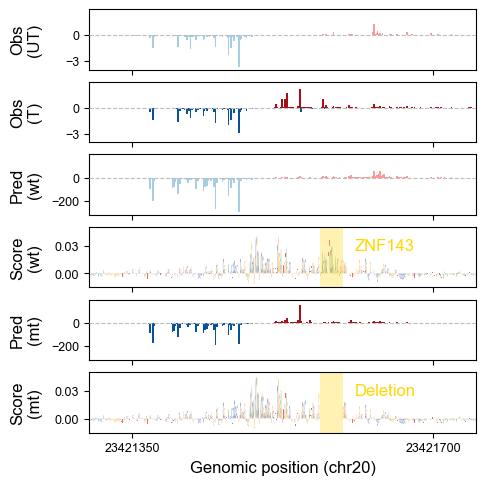

In [20]:
# minTSS - Up

color = "#FFD700"
ylims = [[-4,3], [-320,200], [-0.015,0.05]]
yticks = [[-3,0], [-200,0], [0,0.03]]
xlims = [0,450]
outputfile = f"{PROJECT_DIR_o}figures/SuppFig25c.pdf"
PROcap_contribution_scores(obs_profs, pred_profs, scores, regions[0], color, ylims, yticks, xlims, outputfile)

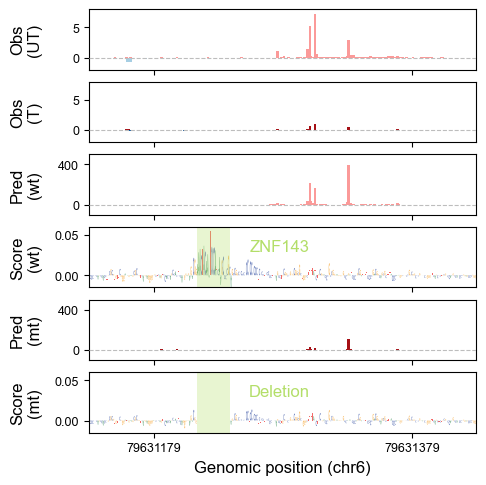

In [21]:
# maxTSS - Down

color = "#b3de69"
ylims = [[-2,8], [-100,500], [-0.015,0.06]]
yticks = [[0,5], [0,400], [0,0.05]]
xlims = [150,450]
outputfile = f"{PROJECT_DIR_o}figures/SuppFig25d.pdf"
PROcap_contribution_scores(obs_profs, pred_profs, scores, regions[1], color, ylims, yticks, xlims, outputfile)

# Metaplots

## Get sequences

In [22]:
# Generate 1-kb sequences (original vs. mutant) anchored on motif center for prediction

def get_sequences2(inputfiles, outputfile, fdict, t, motifs):
	seqs = []
	signs = {}
	for inputfile in inputfiles:
		with DelimitedReader(inputfile) as dr:
			for cols in dr:
				chrom, start, end = cols[:3]
				e = "_".join([chrom, start, end])
				if e in motifs:
					signs[e] = cols[-1]
					center, strand, motif_pattern = motifs[e][0], motifs[e][-2], motifs[e][-1]
					# This is a composite motif of THAP11-ZNF143; align them at ZNF143 core motif
					if motif_pattern == "THAP11-ZNF143":
						center = center + 4 if strand == "+" else center - 4
					seq = fdict[chrom][center-500:center+500].seq.upper()
					wt_seq = one_hot_encode(seq)
					if t == "wt":
						seqs.append(wt_seq.T)
					else:
						mstart = motifs[e][1]
						# in-silico deletion: replace motif instance with [0,0,0,0]
						mt_seq = wt_seq
						for i in range(500-(center-mstart), 500+(center-mstart)+1):
							mt_seq[i] = [0,0,0,0]
						seqs.append(mt_seq.T)
	seqs = np.array(seqs)
	np.save(outputfile, seqs)
	return signs

In [23]:
# Anchor on motif center, generate 1-kb sequences (original vs. mutant) for prediction

signs = {}
for d in ds:
	inputfiles = [f"{PROJECT_DIR_d}bed_plot/{s}_{p}_{d}.bed" for p in ps]
	for t in types:
		outputfile = f"{PROJECT_DIR_o}procapnet/prediction/{s}_{d}_{factor}_{t}.npy"
		signs[(d,t)] = get_sequences2(inputfiles, outputfile, fdict, t, motifs)

## Prediction

In [24]:
# Add GPU at the end

script = f"{PROJECT_DIR_s}slurm/predict.sh"
scale = "True"
model_type = "strand_merged_umap"
for d, t in itertools.product(ds, types):
	inputfile = f"{PROJECT_DIR_o}procapnet/prediction/{s}_{d}_{factor}_{t}.npy"
	output_prefix = f"{PROJECT_DIR_o}procapnet/prediction/{s}_{d}_{factor}_{t}."
	commands = ["sbatch", script,
				s,
				model_type,
				f"{PROJECT_DIR_o}procapnet/",
				inputfile,
				output_prefix,
				scale,
				str(ds.index(d))
				]
	print(" ".join(commands))

sbatch /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/softwares/procapnet/slurm/predict.sh HEK293T strand_merged_umap /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/output/procapnet/ /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/output/procapnet/prediction/HEK293T_distal_ZNF143_wt.npy /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/output/procapnet/prediction/HEK293T_distal_ZNF143_wt. True 0
sbatch /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/softwares/procapnet/slurm/predict.sh HEK293T strand_merged_umap /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/output/procapnet/ /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/output/procapnet/prediction/HEK293T_distal_ZNF143_mt.npy /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/output/procapnet/prediction/HEK293T_distal_ZNF143_mt. True 0
sbatch /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/softwares/pr

In [25]:
def get_matrix(data, signs, tss):
	results = []
	for n in range(data.shape[0]):
		sign = list(signs.values())[n]
		if tss == "maxTSS":
			values = list(data[n][0])+[np.nan] if sign == "+" else [v for v in data[n][1][::-1]]+[np.nan]
		else:
			values = [np.nan]+[-v for v in data[n][1]] if sign == "+" else [np.nan]+[-v for v in data[n][0][::-1]]
		results.append(values)
	df = pd.DataFrame(results, index=list(signs.keys()))
	return df

In [26]:
df_features = {}
for d, t in itertools.product(ds, types):
	data = np.load(f"{PROJECT_DIR_o}procapnet/prediction/{s}_{d}_{factor}_{t}.scaled_profiles.npy")
	for tss in ts:
		df_features[(d,t,tss)] = get_matrix(data, signs[(d,t)], tss)

## Metaplots

In [27]:
# 10-bp bins

df_bins = {}
for k in df_features:
	df_bins[k] = utils.bin_values(df_features[k])

In [28]:
df_reformat = {}
for k in df_bins:
	df = df_bins[k].reset_index()
	df_reformat[k] = pd.melt(df,
							  id_vars="index",
							  value_vars=list(df.columns[1:]),
							  var_name="Position",
							  value_name="Feature"
							  )

In [29]:
DE_labels = json_load(f"{PROJECT_DIR_o}labels/{s}_{factor}_DE.json")

In [30]:
# Source data for SuppFig. 25a & b

df_metaplots = {}
for d, tss in itertools.product(ds, ts):
	label = "Up" if tss == "minTSS" else "Down"
	dfs = []
	for t in types:
		df = df_reformat[(d,t,tss)]
		filtered_df = df[df["index"].isin([k for k, v in DE_labels[tss].items() if v == label])].copy()
		filtered_df["Label"] = f"{tss} ({t})"
		dfs.append(filtered_df)
	df_metaplots[(d,tss)] = pd.concat(dfs).reset_index(drop=True)	
	if d == "proximal":
		df_metaplots[(d,tss)].to_csv(f"{PROJECT_DIR_o}source_data/SuppFig25ab/{d}_{tss}.txt", sep="\t", index=False)

In [31]:
for d, tss in itertools.product(ds, ts):
	maxs = []
	mins = []
	df = df_metaplots[(d,tss)]
	for t in types:
		maxs.append(df[df["Label"]==f"{tss} ({t})"].groupby("Position")["Feature"].mean().max())
		mins.append(df[df["Label"]==f"{tss} ({t})"].groupby("Position")["Feature"].mean().min())
	print(d, tss, max(maxs), min(mins))

distal minTSS -0.30059563629272035 -63.56788201164454
distal maxTSS 23.164922361390392 0.24985687388149658
proximal minTSS -1.2511862730320034 -75.93102028271893
proximal maxTSS 101.07962165007241 0.7230222681234864


In [32]:
def generate_metaplot(d, tss, df_metaplots, ylims, yticks, outputfile, xlabel="Distance to motif (bp)"):
	fig, ax = plt.subplots(figsize=(4.5,2.5))
	labelpad = 2

	hue_order = [f"{tss} ({t})" for t in types]
	if tss == "minTSS":
		palette = ["#a6cee3", "#08519c"]
		label = "Up"
	else:
		palette = ["#fb9a99", "#a50f15"]
		label = "Down"	
	
	df = df_metaplots[(d,tss)]
	sns.lineplot(data=df, x="Position", y="Feature", hue="Label", hue_order=hue_order, palette=palette, ax=ax, errorbar="se")
	
	ax.spines[["right", "top"]].set_visible(False)
	ax.spines['left'].set_position(('outward', 10))
	ax.spines['bottom'].set_position(('outward', 10))
	
	tot = len(set(df["index"]))
	ax.set_title(f"{label} (n={tot})", fontsize=bfontsize, pad=labelpad+5)
	loc = "lower right" if tss == "minTSS" else "upper left"
	ax.legend(loc=loc, fontsize=sfontsize)

	ax.set_ylim(ylims)
	ax.set_yticks(yticks)
	ax.set_yticklabels([str(y) for y in yticks])
	ax.set_ylabel("Predicted", fontsize=bfontsize)
	if tss == "minTSS":
		ax.yaxis.set_label_coords(-0.15, 0.5)
	else:
		ax.yaxis.set_label_coords(-0.12, 0.5)
		
	xticklabel_list = ["-200", "", "", "", "0", "", "", "", "200"]
	xtick_list = [4+n*5 for n in range(9)]
	ax.set_xlim([0,48])
	ax.set_xticks(xtick_list)
	ax.set_xticklabels(xticklabel_list)
	ax.set_xlabel(xlabel, fontsize=bfontsize)
	
	ax.tick_params(labelsize=sfontsize, pad=labelpad)

	ax.axhline(y=0, color="#bdbdbd", ls="--", lw=lw)
	ax.axvline(x=24, ymin=-0.1, ymax=1, color="#bdbdbd", ls="--", lw=lw, clip_on=False, zorder=1)

	plt.savefig(outputfile, bbox_inches="tight", transparent=True)

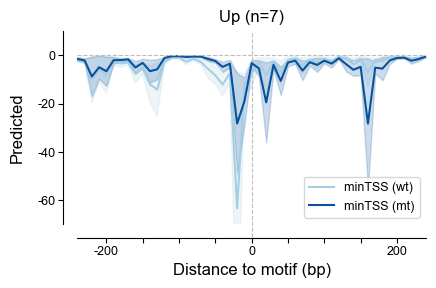

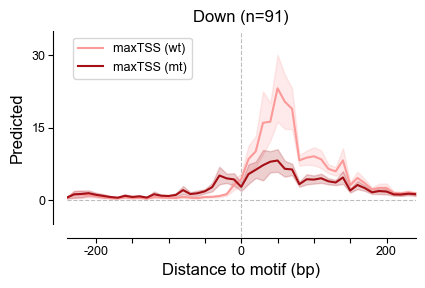

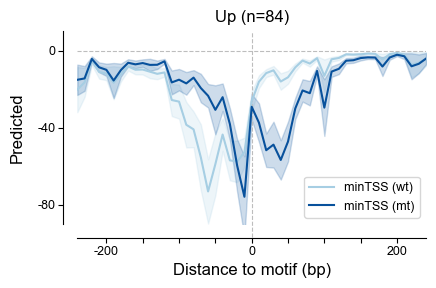

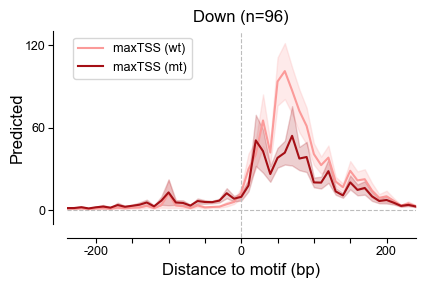

In [33]:
for d in ds:
	folder = "figures/" if d == "proximal" else "other_figures/"
	for tss in ts:
		if tss == "minTSS":
			outputfile = f"{PROJECT_DIR_o}{folder}SuppFig25a.pdf"
			if d == "distal":
				ylims = [-70, 10]
				yticks = [-60, -40, -20, 0]
			else:
				ylims = [-90, 10]
				yticks = [-80, -40, 0]
		else:
			outputfile = f"{PROJECT_DIR_o}{folder}SuppFig25b.pdf"
			if d == "distal":
				ylims = [-5, 35]
				yticks = [0, 15, 30]
			else:
				ylims = [-10, 130]
				yticks = [0, 60, 120]
		generate_metaplot(d, tss, df_metaplots, ylims, yticks, outputfile)